In [ ]:
!kaggle datasets download -d "ikrambenabd/malimg-original"

Dataset URL: https://www.kaggle.com/datasets/ikrambenabd/malimg-original
License(s): unknown
100% 1.09G/1.09G [00:14<00:00, 82.1MB/s]



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import zipfile
import os

# Unzip the dataset if it hasn't been unzipped already
zip_file_path = '/content/malimg-original.zip'
extract_dir = '/content/malimg-original/'

if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"Dataset unzipped to {extract_dir}")
else:
    print(f"Dataset already unzipped to {extract_dir}")

# List the contents of the unzipped directory
print("\nContents of the MalImg dataset:")
for root, dirs, files in os.walk(extract_dir):
    level = root.replace(extract_dir, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

Dataset unzipped to /content/malimg-original/

Contents of the MalImg dataset:
/
malimg_paper_dataset_imgs/
    Lolyda.AA3/
        00597f18fd90baa3a4c7b7eb837fd7f7.png
        007a926e49efb5b943b49f874cf6479b.png
        00e631fdf3851c31146e4de1ace2f1c6.png
        00af7e9bf6b3c68be9327f48f67961da.png
        00360976c2d2eb320521231091f42113.png
        005e607b952e6e92994f9a3d30aa7155.png
        001fb62249f20f9694f2355de8e346de.png
        00e59571a2b251d366355ab55657c621.png
        0082d2ac162488719aa11f67a6fe717c.png
        00df632f4d455cebb677c74134afa2bd.png
        000e2eef7f21958f255415f53321cbfd.png
        00ad0de6958952bb7060ce0a105ece6b.png
        00e1e7804975da1a6558309c5b834caa.png
        006c9c63c5f8b888d72874d798f66f3c.png
        00ea1e902143e53680ca31cbcd6e4a62.png
        008d378867463e92da2dd16435351127.png
        00bbe7a1c0b04366bf421dbd8bf3fedf.png
        004d98785679fa5fc7c014f7860f7ca1.png
        00cb9c74fca4562613aa88ebd0519bd1.png
        0000e9e308602

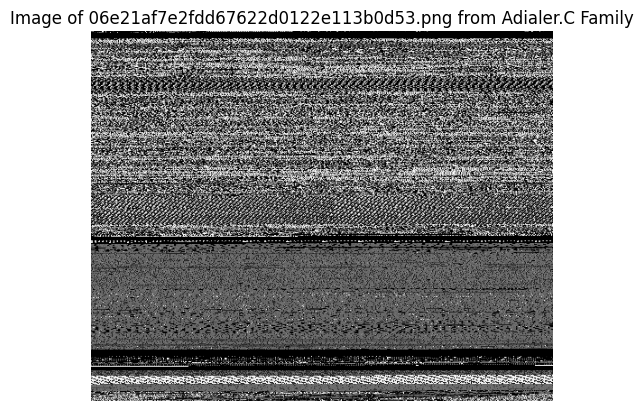

Displayed sample image: 06e21af7e2fdd67622d0122e113b0d53.png from Adialer.C family.


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

# Define the base directory where images are stored
base_image_dir = os.path.join('/content/malimg-original/', 'malimg_paper_dataset_imgs')

# Choose a sample malware family
sample_family = 'Adialer.C'

# Construct the path to the sample family's directory
sample_family_path = os.path.join(base_image_dir, sample_family)

# Get a list of all .png files in the sample family directory
image_files = [f for f in os.listdir(sample_family_path) if f.endswith('.png')]

if image_files:
    # Pick the first image in the list
    sample_image_name = image_files[0]
    sample_image_path = os.path.join(sample_family_path, sample_image_name)

    # Load and display the image
    img = Image.open(sample_image_path)
    plt.imshow(img, cmap='gray') # Most of these images are grayscale
    plt.title(f'Image of {sample_image_name} from {sample_family} Family')
    plt.axis('off') # Hide axes
    plt.show()
    print(f"Displayed sample image: {sample_image_name} from {sample_family} family.")
else:
    print(f"No images found in the {sample_family} family directory.")

In [ ]:
import os

# Define the base directory where images are stored
base_image_dir = os.path.join(extract_dir, 'malimg_paper_dataset_imgs')

# Dictionary to store the count of images per malware family
malware_family_counts = {}

# Iterate through each subdirectory (malware family) in the base directory
if os.path.exists(base_image_dir):
    for family_name in os.listdir(base_image_dir):
        family_path = os.path.join(base_image_dir, family_name)
        if os.path.isdir(family_path):
            # Count the number of .png files in the current family directory
            image_count = len([f for f in os.listdir(family_path) if f.endswith('.png')])
            malware_family_counts[family_name] = image_count

# Display the counts
if malware_family_counts:
    print("Number of images per malware family:")
    for family, count in sorted(malware_family_counts.items()):
        print(f"- {family}: {count} images")
else:
    print("No image directories found or no images counted.")

Number of images per malware family:
- Adialer.C: 122 images
- Agent.FYI: 116 images
- Allaple.A: 2949 images
- Allaple.L: 1591 images
- Alueron.gen!J: 198 images
- Autorun.K: 106 images
- C2LOP.P: 146 images
- C2LOP.gen!g: 200 images
- Dialplatform.B: 177 images
- Dontovo.A: 162 images
- Fakerean: 381 images
- Instantaccess: 431 images
- Lolyda.AA1: 213 images
- Lolyda.AA2: 184 images
- Lolyda.AA3: 123 images
- Lolyda.AT: 159 images
- Malex.gen!J: 136 images
- Obfuscator.AD: 142 images
- Rbot!gen: 158 images
- Skintrim.N: 80 images
- Swizzor.gen!E: 128 images
- Swizzor.gen!I: 132 images
- VB.AT: 408 images
- Wintrim.BX: 97 images
- Yuner.A: 800 images


In [ ]:
import tensorflow as tf
import pathlib
print("GPU:", tf.test.gpu_device_name())
print("Mixed precision:", tf.keras.mixed_precision.global_policy())

GPU: 
Mixed precision: <DTypePolicy "float32">


In [ ]:
IMG_SIZE    = (96, 96)
BATCH_SIZE  = 128
AUTOTUNE    = tf.data.AUTOTUNE
NUM_CLASSES = 25
DATA_DIR    = pathlib.Path("malimg-original/malimg_paper_dataset_imgs")

# Gather all paths and labels
all_paths   = sorted(DATA_DIR.glob("*/*.png"))
class_names = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
class_to_idx = {c: i for i, c in enumerate(class_names)}

paths  = [str(p) for p in all_paths]
labels = [class_to_idx[pathlib.Path(p).parent.name] for p in paths]

print(f"Total images : {len(paths)}")
print(f"Classes      : {len(class_names)}")

# Stratified split
np.random.seed(42)
idx   = np.random.permutation(len(paths))
split = int(0.8 * len(idx))
train_idx, val_idx = idx[:split], idx[split:]

Total images : 9339
Classes      : 25


In [ ]:
def load(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=1)        # grayscale
    img = tf.image.resize(img, IMG_SIZE)               # [0, 255] float
    img = tf.image.grayscale_to_rgb(img)               # 1ch → 3ch for MobileNetV2
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)  # → [-1, 1]
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)            # fine for malware images
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    return img, label

def make_dataset(indices, augment_data=False):
    p = [paths[i] for i in indices]
    l = [labels[i] for i in indices]
    ds = tf.data.Dataset.from_tensor_slices((p, l))
    ds = ds.map(load, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.shuffle(2000).batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_idx, augment_data=True)
val_ds   = make_dataset(val_idx,   augment_data=False)

print(f"Train batches : {len(train_ds)}")
print(f"Val batches   : {len(val_ds)}")

Train batches : 59
Val batches   : 15


In [ ]:
def build_model(trainable_base=False):
    base = tf.keras.applications.MobileNetV2(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = trainable_base

    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = base(inputs, training=False)  # keeps BN frozen even during fine-tune
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)

    return tf.keras.Model(inputs, outputs), base

model, base_model = build_model(trainable_base=False)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         6,425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,592,345 (9.89 MB)

 Trainable params: 334,361 (1.28 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
def make_callbacks(phase):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=5 if phase == 1 else 8,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=SAVE_PATH + f'phase{phase}_best.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]

In [ ]:
SAVE_PATH = 'checkpoints/'

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("=" * 40)
print("Phase 1 — training head only (base frozen)")
print("=" * 40)

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=make_callbacks(phase=1)
)

Phase 1 — training head only (base frozen)
Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6265 - loss: 1.4039
Epoch 1: val_accuracy improved from None to 0.90203, saving model to checkpoints/phase1_best.keras

Epoch 1: finished saving model to checkpoints/phase1_best.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.7771 - loss: 0.8149 - val_accuracy: 0.9020 - val_loss: 0.3060 - learning_rate: 0.0010
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 964ms/step - accuracy: 0.8972 - loss: 0.3408
Epoch 2: val_accuracy improved from 0.90203 to 0.93094, saving model to checkpoints/phase1_best.keras

Epoch 2: finished saving model to checkpoints/phase1_best.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.9056 - loss: 0.3210 - val_accuracy: 0.9309 - val_loss: 0.2151 - learning_rate: 0.0010
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 936ms/step - accuracy: 0.9132 - loss: 0.2857
Epoch 3: val_accuracy improved from 0.93094 to 0.93630, saving model to checkpoints/phase1_be

In [ ]:
# Unfreeze top 30 layers only — keep early feature detectors frozen
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Must recompile after changing trainability
# LR must be much lower — prevents destroying pretrained weights
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("=" * 40)
print("Phase 2 — fine-tuning top 30 layers")
print("=" * 40)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=make_callbacks(phase=2)
)

Phase 2 — fine-tuning top 30 layers
Epoch 1/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4722 - loss: 2.4217
Epoch 1: val_accuracy improved from None to 0.94968, saving model to checkpoints/phase2_best.keras

Epoch 1: finished saving model to checkpoints/phase2_best.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.5897 - loss: 1.7843 - val_accuracy: 0.9497 - val_loss: 0.1300 - learning_rate: 1.0000e-05
Epoch 2/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8157 - loss: 0.7237
Epoch 2: val_accuracy improved from 0.94968 to 0.95075, saving model to checkpoints/phase2_best.keras

Epoch 2: finished saving model to checkpoints/phase2_best.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.8383 - loss: 0.6363 - val_accuracy: 0.9507 - val_loss: 0.1320 - learning_rate: 1.0000e-05
Epoch 3/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8765 - loss: 0.4690
Epoch 3: val_accuracy improved from 0.95075 to 0.95128, saving model to checkpoints/phase2_best.

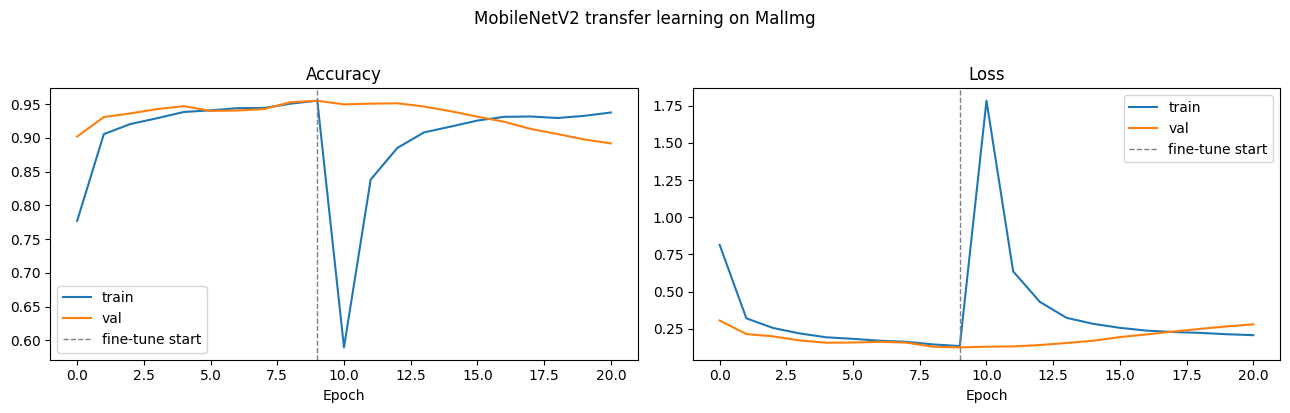

In [ ]:
import matplotlib.pyplot as plt

acc      = history1.history['accuracy']     + history2.history['accuracy']
val_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss     = history1.history['loss']         + history2.history['loss']
val_loss = history1.history['val_loss']     + history2.history['val_loss']

phase1_end = len(history1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

for ax, train, val, title in [
    (ax1, acc,  val_acc,  'Accuracy'),
    (ax2, loss, val_loss, 'Loss')
]:
    ax.plot(train, label='train')
    ax.plot(val,   label='val')
    ax.axvline(phase1_end - 1, color='gray', linestyle='--', linewidth=1, label='fine-tune start')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()

plt.suptitle('MobileNetV2 transfer learning on MalImg', y=1.02)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'training_curves.png', dpi=150)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                precision    recall  f1-score   support

     Adialer.C       1.00      1.00      1.00        25
     Agent.FYI       1.00      1.00      1.00        23
     Allaple.A       0.97      0.99      0.98       595
     Allaple.L       0.99      0.97      0.98       320
 Alueron.gen!J       1.00      1.00      1.00        48
     Autorun.K       0.00      0.00      0.00        17
       C2LOP.P       0.81      0.71      0.76        31
   C2LOP.gen!g       0.77      0.95      0.85        42
Dialplatform.B       1.00      1.00      1.00        37
     Dontovo.A       1.00      1.00      1.00        30
      Fakerean       1.00      1.00      1.00        73
 Instantaccess       0.96      1.00      0.98        77
    Lolyda.AA1       0.95      1.00      0.97        38
    Lolyda.AA2       1.00      0.94      0.97        34
    Lolyda.AA3       1.00      1.00      1.00        28
     Lolyda.AT       1.00      1.00      1.00        35
   Malex.gen!J       0.87      1.00      0.93  

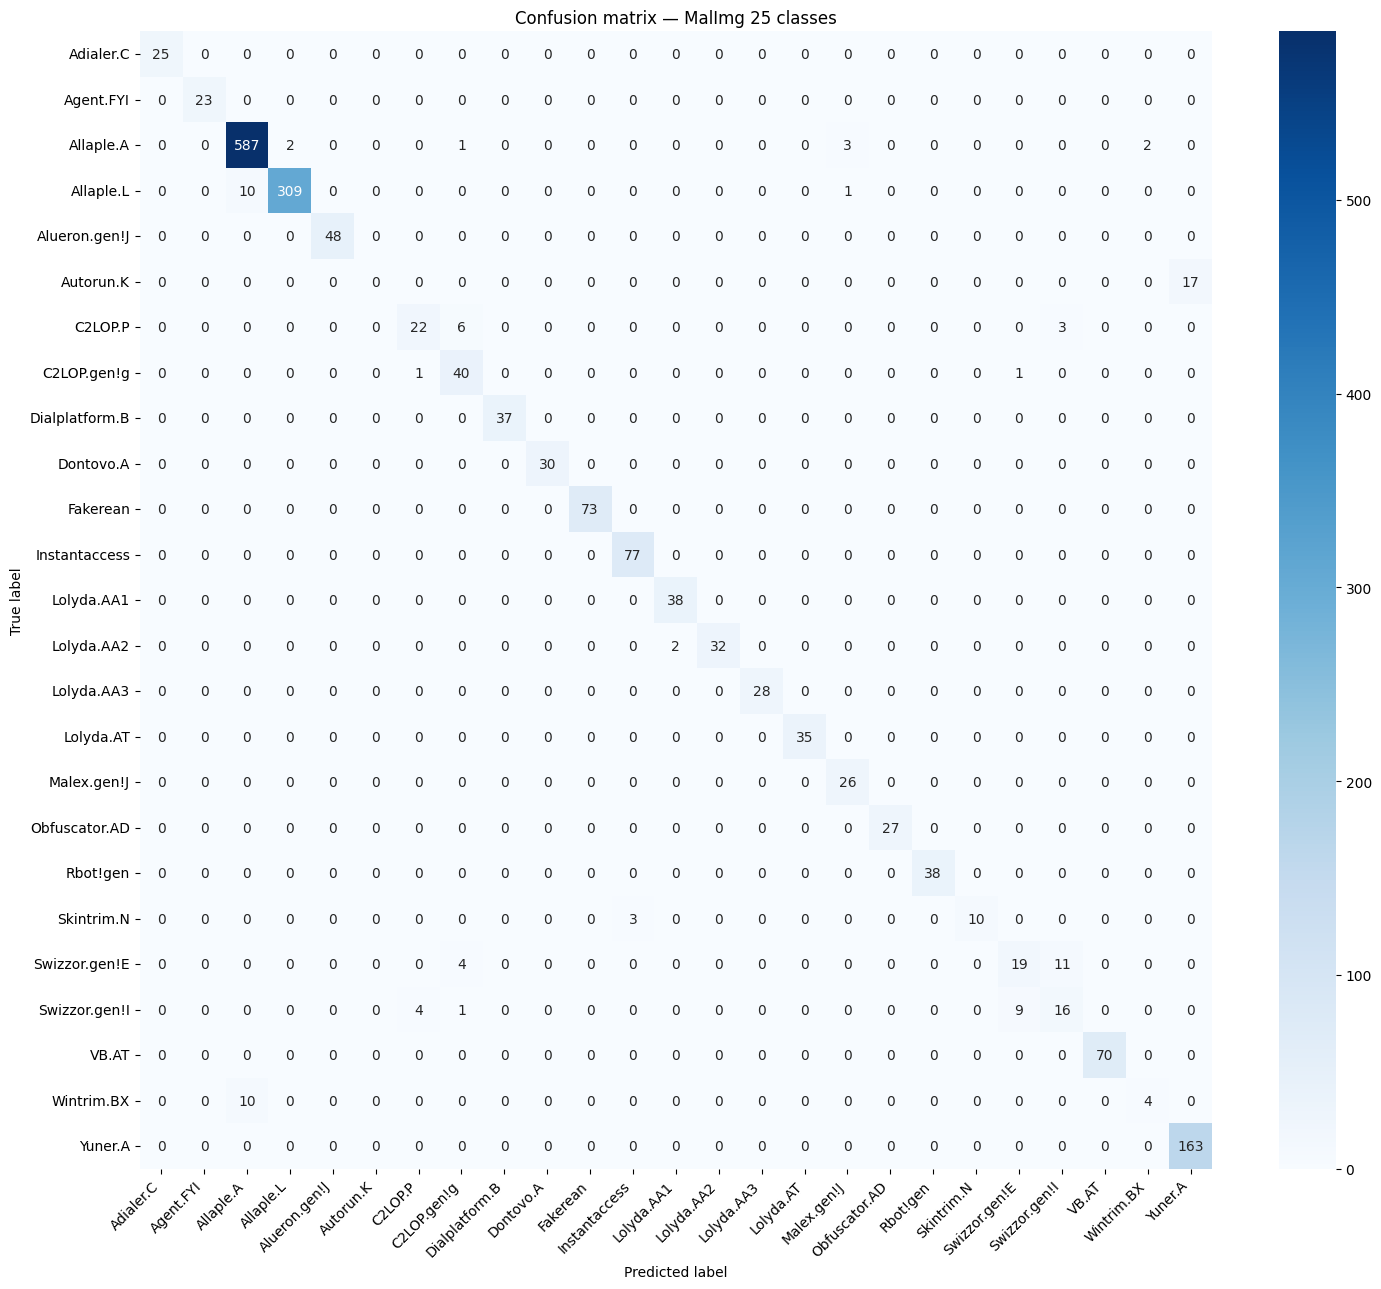

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

all_preds, all_labels = [], []
for imgs, lbls in val_ds:
    preds = model.predict(imgs, verbose=0)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(lbls.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(15, 13))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion matrix — MalImg 25 classes')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(SAVE_PATH + 'confusion_matrix.png', dpi=150)
plt.show()